# Data Formatting

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import cvxpy as cp
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import statsmodels.api as sm
import matplotlib.ticker as mticker

from sklearn.linear_model import LinearRegression
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import (check_X_y, check_array,check_is_fitted)
from statsmodels.tsa.arima_process import ArmaProcess
from google.colab import files
from google.colab import drive
drive.mount('/mnt/drive', force_remount=True)
from matplotlib import pyplot as plt
from cycler import cycler
from collections import defaultdict

Mounted at /mnt/drive


In [ ]:
df_1 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_ct_filtered.csv")).rename(columns={"FIPS5": "FIPS"})
df_2 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_zip_filtered.csv"))
df_2['state'] = df_2['FIPS'].astype(str).str[0:2]
geo_city_df = pd.concat([df_1[['GEOID', 'city']], df_2[['GEOID', 'city']]]).drop_duplicates()

df_dis =pd.read_csv("/mnt/drive/MyDrive/Colab_data/Disaster.csv")

In [ ]:
# Get record from FEMA API
url = "https://www.fema.gov/api/open/v2/DisasterDeclarationsSummaries?$format=csv&$allrecords=true"

# Make it to dataframe
dec = pd.read_csv(url)

# Make FIPS code
dec['fipsStateCode'] = dec['fipsStateCode'].astype(str).str.zfill(2)
dec['fipsCountyCode'] = dec['fipsCountyCode'].astype(str).str.zfill(3)
dec['FIPS'] = dec['fipsStateCode'] + dec['fipsCountyCode']
dec['FIPS'] = dec['FIPS'].astype(str).copy()

# Get a simpler dec
dec = dec[['disasterNumber', 'state', 'designatedArea', 'fipsStateCode', 'fipsCountyCode', 'FIPS']].copy()
dec = pd.merge(dec, df_dis, left_on='disasterNumber', right_on='Num', how='left').copy()
dec = dec.dropna(subset=["month_num"]).copy()

In [ ]:
sc_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/SC_ct.csv")
sc_ct['GEOID'] = sc_ct['TRACT'].astype(str).copy()
HD_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/HD_ct.csv")
HD_ct = HD_ct.dropna(subset=['TRACT']).copy()
HD_ct['GEOID'] = HD_ct['TRACT'].astype(int).astype(str).str.zfill(11)
acs_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/acs_ct.csv")
acs_ct['GEOID'] = acs_ct['GEOID'].astype(str).copy()

In [ ]:
sc_zip =pd.read_csv("/mnt/drive/MyDrive/Colab_data/SC.csv")
sc_zip = sc_zip.dropna(subset=['zip']).copy()
sc_zip['GEOID'] = sc_zip['zip'].astype(int).astype(str).str.zfill(5)
HD_zip =pd.read_csv("/mnt/drive/MyDrive/Colab_data/HD_zip.csv")
HD_zip['zipCode'] = HD_zip['zipCode'].astype(str).str.strip()
HD_zip['zipCode_clean'] = HD_zip['zipCode'].str.extract(r'(\d+)', expand=False)
HD_zip = HD_zip.dropna(subset=['zipCode_clean']).copy()
HD_zip['GEOID'] = HD_zip['zipCode_clean'].astype(int).astype(str).str.zfill(5)
acs_zip =pd.read_csv("/mnt/drive/MyDrive/Colab_data/acs_zip.csv")
acs_zip['GEOID'] = acs_zip['GEOID'].astype(int).astype(str).str.zfill(5)

In [ ]:
import pandas as pd

def row_bind_common(df1, df2):
    common_cols = list(set(df1.columns).intersection(set(df2.columns)))
    return pd.concat([df1[common_cols], df2[common_cols]], axis=0, ignore_index=True)

sc_all = row_bind_common(sc_zip, sc_ct)
HD_all = row_bind_common(HD_zip, HD_ct)
acs_all = row_bind_common(acs_zip, acs_ct)

In [ ]:
# CSV
df_fil_ct = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/filtered_cum_att_all.csv").T.iloc[1:]
df_fil_zip = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/filtered_cum_att_all_zip.csv").T.iloc[1:]
df_combined = pd.concat([df_fil_ct, df_fil_zip])

df_combined = df_combined.reset_index()
df_combined = df_combined.rename(columns={'index': 'disaster_GEOID'})
df_combined[['disasterNumber', 'GEOID']] = df_combined['disaster_GEOID'].str.split('_', expand=True)

df_combined['disasterNumber'] = df_combined['disasterNumber'].astype(str)
df_combined['GEOID'] = df_combined['GEOID'].astype(str)
df_combined = df_combined.drop(columns=['disaster_GEOID'])

df_combined.head()

new_columns = [str(i) for i in range(-12, 13)] + ['disasterNumber'] + ['GEOID']   # -12〜12
df_combined.columns = new_columns

# Combine GEOID+city
geo_city_df = pd.concat([df_1[['GEOID', 'city']], df_2[['GEOID', 'city']]]).drop_duplicates()

df_combined['GEOID'] = df_combined['GEOID'].astype(str)
geo_city_df['GEOID'] = geo_city_df['GEOID'].astype(str)

# Merge
df_combined_with_city = df_combined.merge(
    geo_city_df,
    on='GEOID',
    how='left'
)


disaster_type_dict = {
    "4755": "Severe Storm (2023)",
    "4729": "Severe Storm (2023/06)",
    "4735": "Severe Storm (2023/07)",
    "4665": "Flood (2022)",
    "4651": "Snowstorm (2022)",
    "4645": "Severe Storm (2022)",
    "4637": "Tornado (2022)",
    "4601": "Tornado (2021)",
    "4594": "Severe Ice Storm (2021)",
    "4751": "Severe Storm (2021)",
    "4734": "Hurricane (2023)",
    "4712": "Severe Storm (2023)",
    "4709": "Flood (2023)",
    "4644": "Severe Storm (2022)",
    "4602": "Severe Ice Storm (2021)"
}

df_combined_with_city["disaster_type"] = df_combined_with_city["disasterNumber"].astype(str).map(disaster_type_dict)
disaster_list = dec["disasterNumber"].unique().astype(str)

In [ ]:
# Get record from FEMA API
url = "https://www.fema.gov/api/open/v2/DisasterDeclarationsSummaries?$format=csv&$allrecords=true"

# Make it to dataframe
dec = pd.read_csv(url)

# Make FIPS code
dec['fipsStateCode'] = dec['fipsStateCode'].astype(str).str.zfill(2)
dec['fipsCountyCode'] = dec['fipsCountyCode'].astype(str).str.zfill(3)
dec['FIPS'] = dec['fipsStateCode'] + dec['fipsCountyCode']
dec['FIPS'] = dec['FIPS'].astype(str).copy()

# Get a simpler dec
dec = dec[['disasterNumber', 'state', 'designatedArea', 'fipsStateCode', 'fipsCountyCode', 'FIPS']].copy()
dec = pd.merge(dec, df_dis, left_on='disasterNumber', right_on='Num', how='left').copy()
dec = dec.dropna(subset=["month_num"]).copy()

# Hisogram

In [ ]:
# --- Filter cum_df for month = 12 ---
cum_df_12 = df_combined.iloc[:, 24:27].copy()

# --- Create average filings dictionary ---
avg_dict = df_1.groupby("GEOID")["filings_2020_p2"].mean().to_dict()

# --- Merge all necessary data ---
merged_df = cum_df_12.merge(sc_all, on="GEOID", how="left") \
                     .merge(HD_all, on="GEOID", how="left") \
                     .merge(acs_all, on="GEOID", how="left") \
                     .merge(geo_city_df, on="GEOID", how="left")

merged_df = merged_df.rename(columns={"disasterNumber_x": "disaster", "12" : "cum_att"})

# --- Add disaster type column ---
merged_df["disaster_type"] = merged_df["disaster"].astype(str).map(disaster_type_dict)


/tmp/ipython-input-166933798.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(disaster_types_short))
/tmp/ipython-input-166933798.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


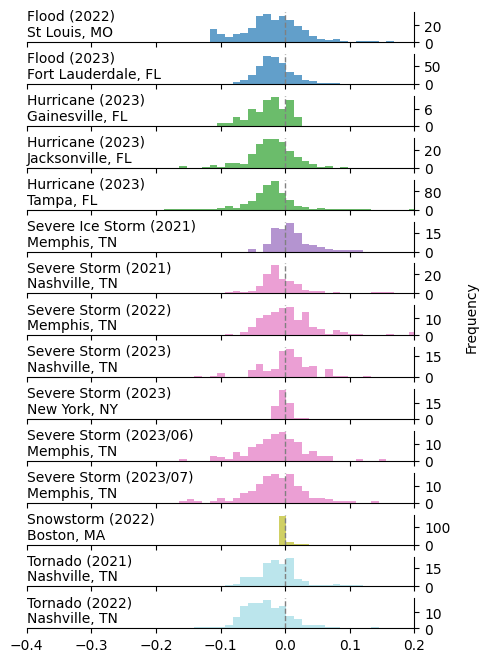

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.api as sm

# -------------------------
# 2. Melt for cumulative ATT history
# -------------------------
month_cols = [str(i) for i in range(-12, 13)]
df_long = df_combined_with_city.melt(
    id_vars=["disasterNumber", "GEOID", "city"],
    value_vars=month_cols,
    var_name="month",
    value_name="cum_att"
)
df_long["month"] = df_long["month"].astype(int)
df_long["disaster_type"] = df_long["disasterNumber"].astype(str).map(disaster_type_dict)

df_long = df_long[df_long["city"] != "Richmond, VA"].copy()

# -------------------------
# 3. Build dictionary mapping (city, disasterNumber, type) -> list of series
# -------------------------
cum_att_by_city_disaster = defaultdict(list)

for (city, dnum, dtype, geo), group in df_long.groupby(["city", "disasterNumber", "disaster_type", "GEOID"]):
    series = pd.Series(data=group["cum_att"].values, index=group["month"].values)
    cum_att_by_city_disaster[(city, dnum, dtype)].append(series)

# mean at t=12
cum_t12_mean = {
    key: np.mean([s.loc[12] for s in series_list if 12 in s.index])
    for key, series_list in cum_att_by_city_disaster.items()
    if any(12 in s.index for s in series_list)
}

# -------------------------
# 4. Sorting Order
# disaster_type -> disasterNumber -> city
# -------------------------
disaster_type_order = sorted(disaster_type_dict.values())  # alphabetical

sorted_keys = sorted(
    cum_t12_mean.keys(),
    key=lambda k: (
        disaster_type_order.index(k[2]),  # disaster type order
        int(k[1]),                        # disaster number numeric
        k[0]                              # city name
    )
)

# -------------------------
# 5. Color Palette by disaster_type
# -------------------------
df_long["disaster_type_short"] = df_long["disaster_type"].str.split("(", n=1).str[0].str.strip()

disaster_types_short = sorted(df_long["disaster_type_short"].dropna().unique())

colors = cm.get_cmap("tab20", len(disaster_types_short))
color_dict_short = {dtype: colors(i) for i, dtype in enumerate(disaster_types_short)}

# -------------------------
# 6. Histogram Plot
# -------------------------
fig_hist = plt.figure(figsize=(5, 8))
n = len(sorted_keys)
gs_hist = gridspec.GridSpec(n, 1, figure=fig_hist, hspace=0.4)

all_obs_values = []
for key in sorted_keys:
    all_obs_values.extend([s.loc[12] for s in cum_att_by_city_disaster[key] if 12 in s.index])
bin_edges = np.linspace(min(all_obs_values), max(all_obs_values), 101)

for i, key in enumerate(sorted_keys):
    ax = fig_hist.add_subplot(gs_hist[i])
    obs_values = [s.loc[12] for s in cum_att_by_city_disaster[key] if 12 in s.index]

    dtype_short = str(key[2]).split("(")[0].strip()

    disaster_label = key[2]
    city = key[0]

    ax.hist(obs_values, bins=bin_edges, color=color_dict_short[dtype_short], alpha=0.7, edgecolor=None)
    ax.axvline(0, color="gray", linestyle="--", linewidth=1)

    ax.set_xlim(-0.4, 0.2)

    ax.text(0, 0.6, f"{disaster_label}\n{city}", transform=ax.transAxes,
            ha='left', va='center', fontsize=10)

    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=2, integer=True))
    ax.tick_params(axis='y', labelleft=False, labelright=True, right=True, left=False, labelsize=10)

    if i < n - 1:
        ax.tick_params(axis='x', labelbottom=False)
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_visible(False)
    else:
        ax.tick_params(axis='x', labelsize=10)
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_visible(False)

fig_hist.text(1, 0.5, "Frequency", va='center', rotation=90, fontsize=10)

plt.tight_layout()
plt.savefig("figure.png", dpi=200)
plt.show()
from google.colab import files
files.download("figure.png")



# Correlation(Ave-ATT, outlier removed)

In [ ]:
# --- Filter cum_df for month = 12 ---
cum_df_12 = df_combined.iloc[:, 24:27].copy()

# --- Create average filings dictionary ---
avg_dict = df_1.groupby("GEOID")["filings_2020_p2"].mean().to_dict()

# --- Merge all necessary data ---
merged_df = cum_df_12.merge(sc_all, on="GEOID", how="left") \
                     .merge(HD_all, on="GEOID", how="left") \
                     .merge(acs_all, on="GEOID", how="left") \
                     .merge(geo_city_df, on="GEOID", how="left")

merged_df = merged_df.rename(columns={"disasterNumber_x": "disaster", "12" : "cum_att"})

# --- Add disaster type column ---
merged_df["disaster_type"] = merged_df["disaster"].astype(str).map(disaster_type_dict)


In [ ]:
# disasterNumber → month_num
disaster_month_dict = (
    dec
    .dropna(subset=["disasterNumber", "month_num"])
    .set_index(dec["disasterNumber"].astype(str))["month_num"]
    .to_dict()
)

### Average 2020-2024

In [ ]:
import pandas as pd

df_1_48 = df_1[df_1["month_num"].between(1, 48)]
df_2_48 = df_2[df_2["month_num"].between(1, 48)]

avg_dict1 = df_1_48.groupby("GEOID")["filings_2020_p2"].mean()*12
avg_dict2 = df_2_48.groupby("GEOID")["filings_2020_p2"].mean()*12

df_avg1 = avg_dict1.reset_index(name="sum_filings_2020_p2")
df_avg2 = avg_dict2.reset_index(name="sum_filings_2020_p2")

df_avg_combined = pd.concat([df_avg1, df_avg2], ignore_index=True)

merged_df["GEOID"] = merged_df["GEOID"].astype(str)
df_avg_combined["GEOID"] = df_avg_combined["GEOID"].astype(str)

merged_df = merged_df.merge(df_avg_combined, on="GEOID", how="left")
merged_df = merged_df[merged_df["state"] != "VA"].copy()

/tmp/ipython-input-2312864556.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(disaster_types_short))


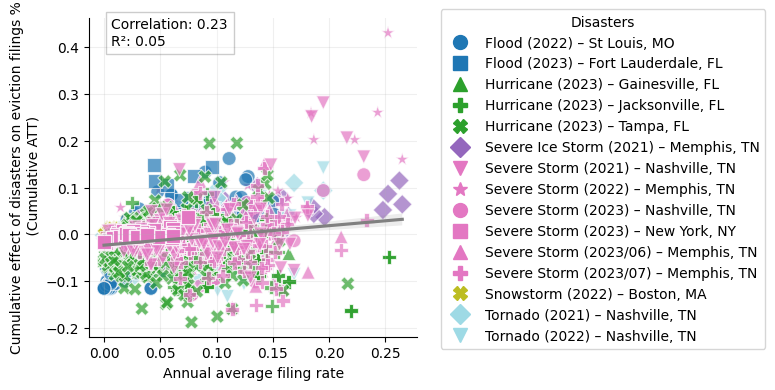

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.cm as cm
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# --- Filter df ---
merged_df = merged_df.dropna(subset=["cum_att", "sum_filings_2020_p2"]).copy()
merged_df["sum_filings_2020_p2"] = pd.to_numeric(merged_df["sum_filings_2020_p2"], errors="coerce")
merged_df["cum_att"] = pd.to_numeric(merged_df["cum_att"], errors="coerce")
merged_df = merged_df.dropna(subset=["cum_att"])

merged_df = merged_df[merged_df["cum_att"]<1.0].copy()

# --- Create label as "Type - City" ---
merged_df["disaster_type_short"] = merged_df["disaster_type"].str.split("(", n=1).str[0].str.strip()
merged_df["label"] = merged_df["disaster_type_short"]
merged_df["label2"] = merged_df["disaster_type_short"] + " - " + merged_df["city"]

# --- Filter data ---
merged_filtered = merged_df.copy()

# --- Create color dictionary based on short disaster_type ---
disaster_types_short = sorted(merged_filtered["disaster_type_short"].dropna().astype(str).unique())
colors = cm.get_cmap("tab20", len(disaster_types_short))
color_dict_type = {dtype: colors(i) for i, dtype in enumerate(disaster_types_short)}

# palette for label (Type - City)
ordered_labels = []
ordered_labels2 = []  # label2: unique shape key

for key in sorted_keys:
    city = key[0]
    disaster_label = key[2]
    dtype_short = str(disaster_label).split("(")[0].strip()

    label = disaster_label
    label2 = f"{disaster_label} - {city}"

    ordered_labels.append(label)
    ordered_labels2.append(label2)

ordered_labels = list(dict.fromkeys(ordered_labels))
ordered_labels2 = list(dict.fromkeys(ordered_labels2))

palette = {
    label: color_dict_type[
        label.split("(")[0].strip()
    ]
    for label in ordered_labels
}

merged_filtered["label_full"] = merged_filtered["disaster_type"]
merged_filtered["label2_full"] = merged_filtered["disaster_type"] + " - " + merged_filtered["city"]

# --- Create order ---
merged_filtered["disasterNumber"] = merged_filtered["disaster"].astype(int)
hue_order = merged_filtered.sort_values(["disaster_type_short", "disasterNumber", "city"])["label"].unique()

# --- Marker styles ---
marker_styles = ['o', 's', '^', 'P', 'X', 'D', 'v', '*']
marker_dict = {
    label2: marker_styles[i % len(marker_styles)]
    for i, label2 in enumerate(ordered_labels2)
}

# --- Plot ---
plt.figure(figsize=(8,4))
sns.scatterplot(
    data=merged_filtered,
    x="sum_filings_2020_p2",
    y="cum_att",
    hue="label_full",
    style="label2_full",
    palette=palette,
    markers=marker_dict,
    hue_order=ordered_labels,
    style_order=ordered_labels2,
    s=100,
    alpha=0.7
)

# --- Regression line ---
sns.regplot(
    data=merged_filtered,
    x="sum_filings_2020_p2",
    y="cum_att",
    scatter=False,
    color="gray"
)

# --- Correlation / R² ---
X = sm.add_constant(merged_filtered["sum_filings_2020_p2"])
y = merged_filtered["cum_att"]
model = sm.OLS(y, X).fit()
r_squared = model.rsquared
corr = merged_filtered["sum_filings_2020_p2"].corr(merged_filtered["cum_att"])

plt.text(
    x=merged_filtered["sum_filings_2020_p2"].max()*0.025,
    y=merged_filtered["cum_att"].max(),
    s=f"Correlation: {corr:.2f}\nR²: {r_squared:.2f}",
    fontsize=10,
    ha="left",
    va="center",
    bbox=dict(facecolor="white", alpha=0.2)
)

plt.xlabel("Annual average filing rate", fontsize=10)
plt.ylabel("Cumulative effect of disasters on eviction filings %\n (Cumulative ATT)", fontsize=10)
plt.grid(True, alpha=0.2)

# --- Legend ---
handles = []
for label2 in ordered_labels2:
    disaster_label, city = label2.split(" - ", 1)
    dtype_short = disaster_label.split("(")[0].strip()

    color = palette[disaster_label]
    marker = marker_dict[label2]

    handle = mlines.Line2D(
        [], [],
        color=color,
        marker=marker,
        linestyle='None',
        markersize=10,
        label=f"{disaster_label} – {city}"
    )
    handles.append(handle)

plt.legend(
    handles=handles,
    bbox_to_anchor=(1.05,1.05),
    loc="upper left",
    title="Disasters")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("figure.png", dpi=200)
plt.show()
from google.colab import files
files.download("figure.png")


# Correlation(Demo(logged)-ATT)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

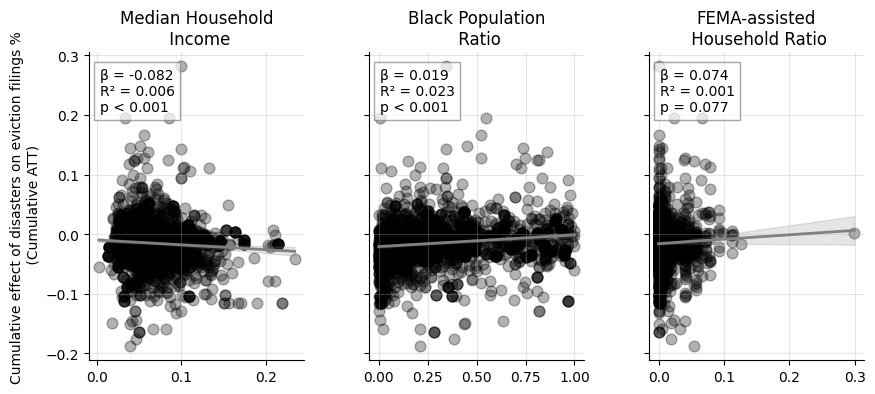

In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import gridspec

# --- Prepare data ---
plot_df = merged_df[['cum_att', 'Median_Household_Income', 'Tre_p', 'Black_Population','Total_Population']].copy()
plot_df = plot_df.dropna()
plot_df['Median_Household_Income'] = plot_df['Median_Household_Income']/1000000
plot_df['D_TH'] = plot_df['Tre_p']
plot_df['Black_Population_Ratio'] = plot_df['Black_Population']/plot_df['Total_Population']

x_vars = ['Median_Household_Income', 'Black_Population_Ratio', 'D_TH']
y_var = 'cum_att'
x_label_mapping = {
    'Median_Household_Income': "Median Household\n Income",
    'D_TH': "FEMA-assisted\n Household Ratio",
    'Black_Population_Ratio': "Black Population\n Ratio"
}

fig = plt.figure(figsize=(10, 4))
gs = fig.add_gridspec(1, len(x_vars), wspace=0.3)

for i, x in enumerate(x_vars):
    # --- Scatter + regression plot ---
    ax_scatter = fig.add_subplot(gs[0, i])
    X = sm.add_constant(plot_df[x])
    y = plot_df[y_var]
    model = sm.OLS(y, X).fit()
    beta = model.params[x]
    p_val = model.pvalues[x]
    r2 = model.rsquared
    p_text = "< 0.001" if p_val < 0.001 else f"= {p_val:.3f}"

    # --- Scatter plot ---
    ax_scatter.scatter(plot_df[x], y, alpha=0.3, color='black', s=60)
    x_range = np.linspace(plot_df[x].min(), plot_df[x].max(), 100)
    X_pred = sm.add_constant(x_range)
    pred = model.get_prediction(X_pred)
    y_pred = pred.predicted_mean
    ci_lower, ci_upper = pred.conf_int().T
    ax_scatter.plot(x_range, y_pred, color='gray', linewidth=2)
    ax_scatter.fill_between(x_range, ci_lower, ci_upper, color='gray', alpha=0.2)

    # --- Statistics box ---
    ax_scatter.text(0.05, 0.95,
                    f"β = {beta:.3f}\nR² = {r2:.3f}\np {p_text}",
                    transform=ax_scatter.transAxes,
                    verticalalignment='top',
                    fontsize=10,
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))
    ax_scatter.grid(alpha=0.3)

    # --- Set column title at the top ---
    ax_scatter.set_title(x_label_mapping.get(x, x), fontsize=12)
    ax_scatter.spines['top'].set_visible(False)
    ax_scatter.spines['right'].set_visible(False)

    if i == 0:
        ax_scatter.set_ylabel("Cumulative effect of disasters on eviction filings %\n (Cumulative ATT)", fontsize=10)
        ax_scatter.tick_params(axis='y', labelleft=True)
    else:
        ax_scatter.set_ylabel("")
        ax_scatter.tick_params(axis='y', labelleft=False)

fig.savefig("figure.png", dpi=200)
fig.show()
from google.colab import files
files.download("figure.png")